# 02 — Simple signal prototype

Prototype a **SMA crossover** on M1 bars: rolling averages, discrete `signal` column, crossover events, chart.
No PnL engine yet — move stable helpers to `src/quant_sandbox/` before porting to C++.

Kernel: **Algo Trading (quant_sandbox)**.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quant_sandbox import load_bars

SYMBOL = "NVDA"
START = "2024-05-01"
LAKE = "data_lake_m1"

FAST = 20   # bars (minutes on M1)
SLOW = 60

PLOT_START = "2024-05-01"
PLOT_END = "2024-05-03"  # chart zoom: a few RTH sessions (not full backtest range)

df = load_bars(SYMBOL, start=START, lake_root=LAKE)
print(f"{SYMBOL} M1: {len(df):,} bars")
print(f"range: {df.index.min()} → {df.index.max()}")

NVDA M1: 200,231 bars
range: 2024-05-01 09:30:00+00:00 → 2026-05-22 10:40:00+00:00


In [3]:
def add_sma_cross(
    frame: pd.DataFrame,
    *,
    fast: int,
    slow: int,
    price_col: str = "close",
) -> pd.DataFrame:
    """Add sma_fast, sma_slow, and signal (+1 long bias, -1 short bias, 0 warmup)."""
    if fast >= slow:
        raise ValueError("fast window must be smaller than slow window")

    out = frame.copy()
    out["sma_fast"] = out[price_col].rolling(fast, min_periods=fast).mean()
    out["sma_slow"] = out[price_col].rolling(slow, min_periods=slow).mean()

    ready = out["sma_fast"].notna() & out["sma_slow"].notna()
    out["signal"] = 0
    out.loc[ready, "signal"] = np.where(
        out.loc[ready, "sma_fast"] > out.loc[ready, "sma_slow"], 1, -1
    )
    return out


def crossover_events(frame: pd.DataFrame) -> pd.DataFrame:
    """Rows where signal flips (bullish / bearish cross)."""
    sig = frame["signal"]
    changed = sig.ne(sig.shift()) & sig.ne(0)
    events = frame.loc[changed, ["close", "sma_fast", "sma_slow", "signal"]].copy()
    events["cross"] = np.where(events["signal"] > 0, "bullish", "bearish")
    return events


signals = add_sma_cross(df, fast=FAST, slow=SLOW)
signals[["close", "sma_fast", "sma_slow", "signal"]].tail()

,close,sma_fast,sma_slow,signal
timestamp,,,,
2026-05-22 10:36:00+00:00,216.57,216.1990,217.286833,-1
2026-05-22 10:37:00+00:00,216.75,216.2245,217.234167,-1
2026-05-22 10:38:00+00:00,216.72,216.2565,217.177167,-1
2026-05-22 10:39:00+00:00,216.76,216.2890,217.114500,-1
2026-05-22 10:40:00+00:00,217.06,216.3390,217.062500,-1


In [4]:
ready = signals["signal"].ne(0)
print(f"warmup bars (signal=0): {(~ready).sum():,}")
print("signal distribution (after warmup):")
print(signals.loc[ready, "signal"].value_counts().sort_index())

events = crossover_events(signals)
print(f"\ncrossover events (full history): {len(events):,}")
print(f"  bullish: {(events['cross'] == 'bullish').sum():,}")
print(f"  bearish: {(events['cross'] == 'bearish').sum():,}")

window = signals.loc[PLOT_START:PLOT_END]
window_events = crossover_events(window)
print(f"\ncrossovers in plot window ({PLOT_START} → {PLOT_END}): {len(window_events)}")
window_events[["close", "sma_fast", "sma_slow", "cross"]]

warmup bars (signal=0): 59
signal distribution (after warmup):
signal
-1     96438
 1    103734
Name: count, dtype: int64

crossover events (full history): 3,933
  bullish: 1,966
  bearish: 1,967

crossovers in plot window (2024-05-01 → 2024-05-15): 72


,close,sma_fast,sma_slow,cross
timestamp,,,,
2024-05-01 10:29:00+00:00,83.75,83.4555,84.259500,bearish
2024-05-01 10:45:00+00:00,83.99,84.0145,84.014000,bullish
2024-05-01 11:09:00+00:00,83.17,83.7370,83.758333,bearish
2024-05-01 12:35:00+00:00,82.19,82.1170,82.116500,bullish
2024-05-01 12:59:00+00:00,81.80,81.9130,81.938000,bearish
...,...,...,...,...
2024-05-15 09:30:00+00:00,92.25,91.4750,91.471500,bullish
2024-05-15 13:10:00+00:00,94.50,94.5250,94.525833,bearish
2024-05-15 13:41:00+00:00,94.54,94.4885,94.479333,bullish


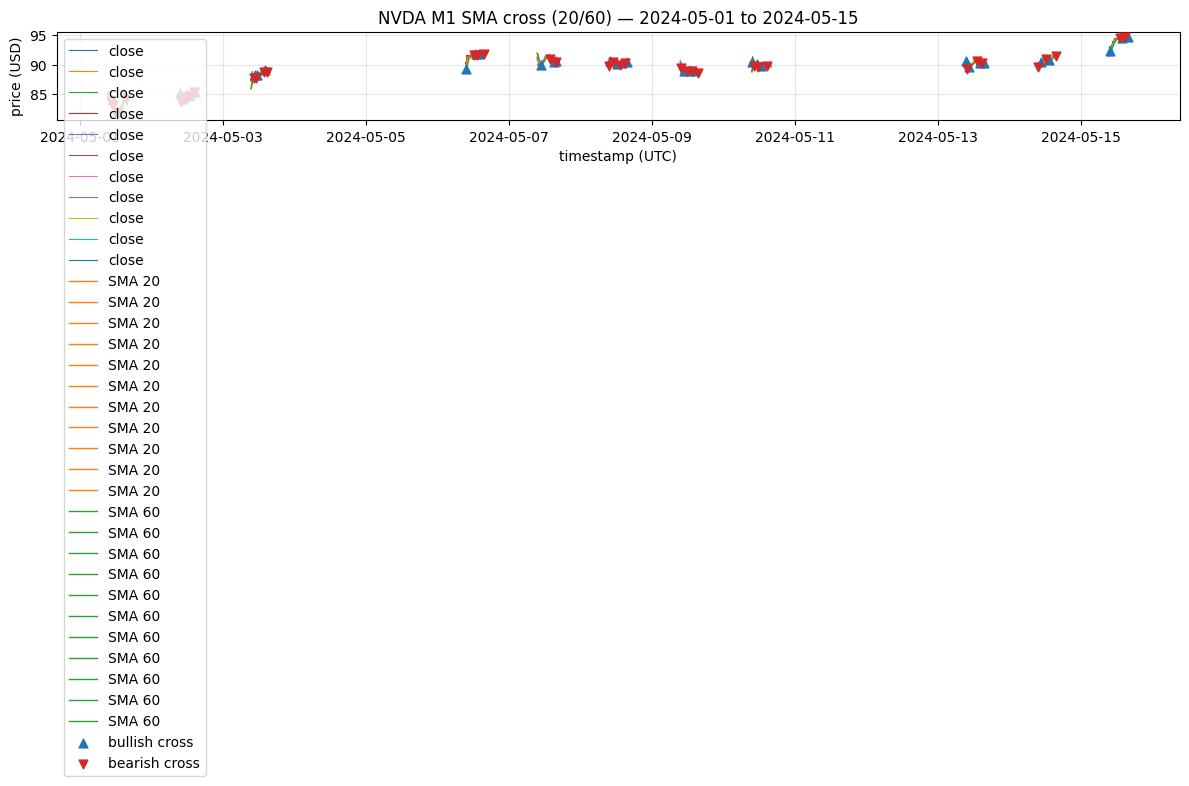

In [5]:
from matplotlib.lines import Line2D


def plot_rth_sessions(ax, frame, column, **plot_kwargs):
    """Plot each trading day separately so overnight gaps stay empty."""
    plot_kwargs.pop("label", None)  # avoid one legend entry per session
    for _, day in frame.groupby(frame.index.normalize()):
        ax.plot(day.index, day[column], **plot_kwargs)


def plot_rth_signal(ax, frame, **plot_kwargs):
    plot_kwargs.pop("label", None)
    for _, day in frame.groupby(frame.index.normalize()):
        ax.step(day.index, day["signal"], where="post", **plot_kwargs)


sample = signals.loc[PLOT_START:PLOT_END]
sample_events = crossover_events(sample)

fig, (ax_price, ax_sig) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, height_ratios=[3, 1], gridspec_kw={"hspace": 0.08}
)

plot_rth_sessions(ax_price, sample, "close", linewidth=0.8, color="C0")
plot_rth_sessions(
    ax_price, sample.dropna(subset=["sma_fast"]), "sma_fast",
    linewidth=1.2, color="tab:orange",
)
plot_rth_sessions(
    ax_price, sample.dropna(subset=["sma_slow"]), "sma_slow",
    linewidth=1.2, color="tab:green",
)

bull = sample_events[sample_events["cross"] == "bullish"]
bear = sample_events[sample_events["cross"] == "bearish"]
ax_price.scatter(bull.index, bull["close"], marker="^", color="tab:blue", s=50, zorder=3)
ax_price.scatter(bear.index, bear["close"], marker="v", color="tab:red", s=50, zorder=3)

ax_price.set_ylabel("price (USD)")
ax_price.set_title(f"{SYMBOL} M1 SMA cross ({FAST}/{SLOW}) — {PLOT_START} to {PLOT_END}")
ax_price.grid(True, alpha=0.3)
ax_price.legend(
    handles=[
        Line2D([0], [0], color="C0", linewidth=0.8, label="close"),
        Line2D([0], [0], color="tab:orange", linewidth=1.2, label=f"SMA {FAST}"),
        Line2D([0], [0], color="tab:green", linewidth=1.2, label=f"SMA {SLOW}"),
        Line2D([0], [0], marker="^", color="w", markerfacecolor="tab:blue", markersize=8, label="bullish cross"),
        Line2D([0], [0], marker="v", color="w", markerfacecolor="tab:red", markersize=8, label="bearish cross"),
    ],
    loc="upper left",
)

plot_rth_signal(ax_sig, sample.loc[sample["signal"].ne(0)], linewidth=1.0, color="tab:purple")
ax_sig.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
ax_sig.set_yticks([-1, 1])
ax_sig.set_yticklabels(["-1 short bias", "+1 long bias"])
ax_sig.set_ylabel("signal")
ax_sig.set_xlabel("timestamp (UTC)")
ax_sig.grid(True, alpha=0.3)
fig.tight_layout()

In [6]:
# Export-friendly view: OHLCV + indicators + signal (last rows of plot window)
export_cols = ["open", "high", "low", "close", "volume", "sma_fast", "sma_slow", "signal"]
sample[export_cols].tail(10)

,open,high,low,close,volume,sma_fast,sma_slow,signal
timestamp,,,,,,,,
2024-05-15 15:50:00+00:00,94.74,94.74,94.64,94.70,1119480.0,94.7685,94.640000,1
2024-05-15 15:51:00+00:00,94.68,94.72,94.64,94.68,875840.0,94.7680,94.640667,1
2024-05-15 15:52:00+00:00,94.68,94.70,94.53,94.54,1139070.0,94.7605,94.638667,1
2024-05-15 15:53:00+00:00,94.55,94.65,94.52,94.63,832790.0,94.7580,94.638000,1
2024-05-15 15:54:00+00:00,94.63,94.72,94.57,94.72,1124580.0,94.7550,94.639000,1
2024-05-15 15:55:00+00:00,94.67,94.72,94.57,94.63,920530.0,94.7475,94.638000,1
2024-05-15 15:56:00+00:00,94.62,94.68,94.59,94.61,1057300.0,94.7385,94.637333,1
2024-05-15 15:57:00+00:00,94.61,94.69,94.59,94.60,951690.0,94.7290,94.636000,1
2024-05-15 15:58:00+00:00,94.60,94.66,94.59,94.65,1348210.0,94.7245,94.635167,1
